# YOLO Training Results Analysis
Visualise and explore `results.csv` from a YOLO classification run.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="darkgrid", palette="muted")

RESULTS_CSV = Path(
    "../runs/classify/data/generated/train2_local_run/single_strategy/runs/single-10/results.csv"
)

df = pd.read_csv(RESULTS_CSV)
df.columns = df.columns.str.strip()
print(f"Epochs loaded: {len(df)}")
df.head()

Epochs loaded: 35


,epoch,time,train/loss,metrics/accuracy_top1,metrics/accuracy_top5,metrics/macro_f1,val/loss,lr/pg0,lr/pg1,lr/pg2
0,1,84.6733,0.95024,0.80917,1,0.64690,0.50906,0.000368,0.000368,0.000368
1,2,170.8430,0.51626,0.84563,1,0.73542,0.42199,0.000717,0.000717,0.000717
2,3,263.7010,0.47019,0.81002,1,0.71589,0.61543,0.001046,0.001046,0.001046
3,4,355.0030,0.43097,0.80171,1,0.71119,0.56088,0.001017,0.001017,0.001017
4,5,443.5010,0.37222,0.88380,1,0.79796,0.33876,0.000985,0.000985,0.000985


## Summary Statistics

In [2]:
best_epoch = df.loc[df["metrics/accuracy_top1"].idxmax()]
print("=== Best Val Accuracy Epoch ===")
print(f"  Epoch         : {int(best_epoch['epoch'])}")
print(f"  Top-1 Accuracy: {best_epoch['metrics/accuracy_top1']:.4f}")
print(f"  Val Loss      : {best_epoch['val/loss']:.4f}")
print(f"  Train Loss    : {best_epoch['train/loss']:.4f}")
print()

lowest_val_loss = df.loc[df["val/loss"].idxmin()]
print("=== Lowest Val Loss Epoch ===")
print(f"  Epoch         : {int(lowest_val_loss['epoch'])}")
print(f"  Val Loss      : {lowest_val_loss['val/loss']:.4f}")
print(f"  Top-1 Accuracy: {lowest_val_loss['metrics/accuracy_top1']:.4f}")

print()
print("=== Final Epoch ===")
last = df.iloc[-1]
print(f"  Epoch         : {int(last['epoch'])}")
print(f"  Top-1 Accuracy: {last['metrics/accuracy_top1']:.4f}")
print(f"  Val Loss      : {last['val/loss']:.4f}")
print(f"  Train Loss    : {last['train/loss']:.4f}")

=== Best Val Accuracy Epoch ===
  Epoch         : 34
  Top-1 Accuracy: 0.9465
  Val Loss      : 0.2072
  Train Loss    : 0.0497

=== Lowest Val Loss Epoch ===
  Epoch         : 25
  Val Loss      : 0.1981
  Top-1 Accuracy: 0.9458

=== Final Epoch ===
  Epoch         : 35
  Top-1 Accuracy: 0.9463
  Val Loss      : 0.2212
  Train Loss    : 0.0441


## Loss Curves (Train vs Val)

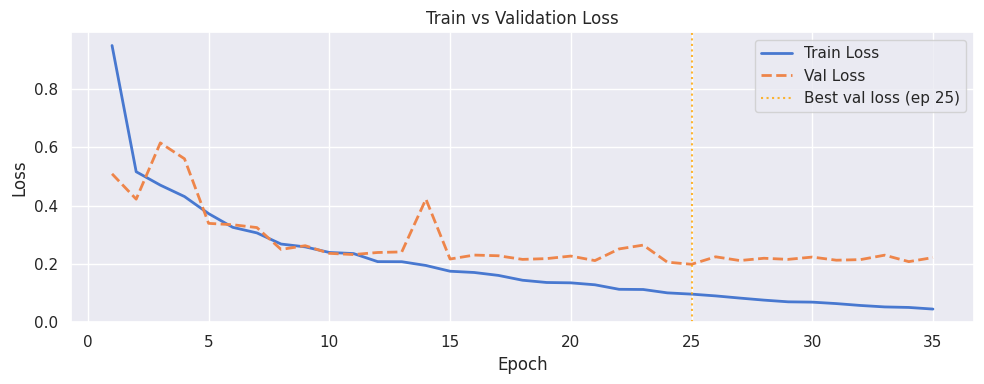

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(df["epoch"], df["train/loss"], label="Train Loss", linewidth=2)
ax.plot(df["epoch"], df["val/loss"], label="Val Loss", linewidth=2, linestyle="--")

# mark best val loss
best_vl = df.loc[df["val/loss"].idxmin()]
ax.axvline(best_vl["epoch"], color="orange", linestyle=":", alpha=0.8, label=f"Best val loss (ep {int(best_vl['epoch'])})")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Train vs Validation Loss")
ax.legend()
plt.tight_layout()
plt.show()

## Top-1 Accuracy Over Epochs

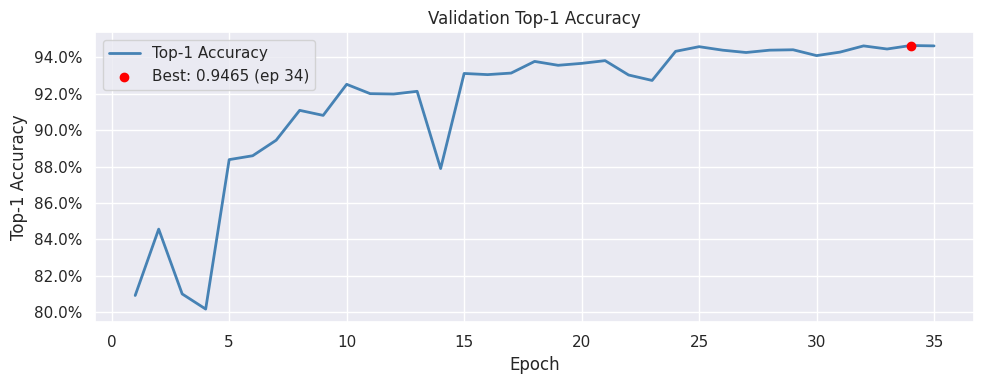

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(df["epoch"], df["metrics/accuracy_top1"], color="steelblue", linewidth=2, label="Top-1 Accuracy")

best_acc = df.loc[df["metrics/accuracy_top1"].idxmax()]
ax.scatter(best_acc["epoch"], best_acc["metrics/accuracy_top1"],
           color="red", zorder=5, label=f"Best: {best_acc['metrics/accuracy_top1']:.4f} (ep {int(best_acc['epoch'])})")

ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_xlabel("Epoch")
ax.set_ylabel("Top-1 Accuracy")
ax.set_title("Validation Top-1 Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

## Overfitting Check: Gap Between Train and Val Loss

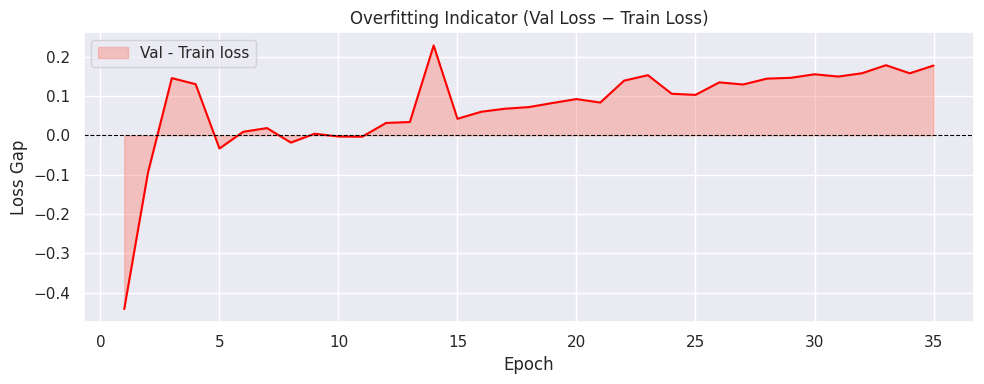

In [5]:
df["loss_gap"] = df["val/loss"] - df["train/loss"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(df["epoch"], df["loss_gap"], alpha=0.4, color="salmon", label="Val - Train loss")
ax.plot(df["epoch"], df["loss_gap"], color="red", linewidth=1.5)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss Gap")
ax.set_title("Overfitting Indicator (Val Loss − Train Loss)")
ax.legend()
plt.tight_layout()
plt.show()

## Learning Rate Schedule

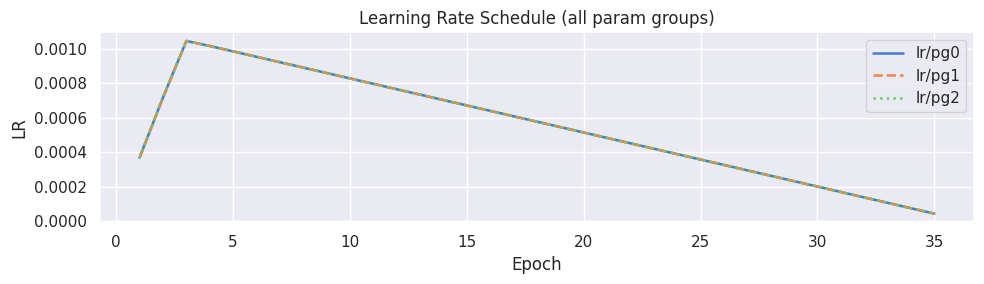

In [6]:
fig, ax = plt.subplots(figsize=(10, 3))

for col, style in [("lr/pg0", "-"), ("lr/pg1", "--"), ("lr/pg2", ":")]:
    if col in df.columns:
        ax.plot(df["epoch"], df[col], label=col, linestyle=style, linewidth=1.8)

ax.set_xlabel("Epoch")
ax.set_ylabel("LR")
ax.set_title("Learning Rate Schedule (all param groups)")
ax.legend()
plt.tight_layout()
plt.show()

## Training Speed (Time per Epoch)

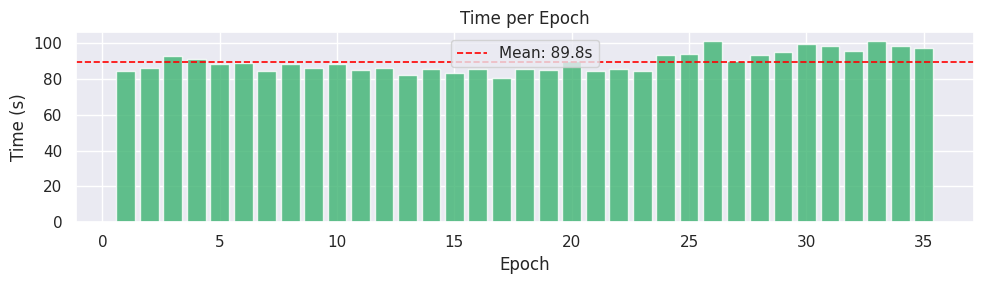

Total training time : 52.4 min (0.87 hr)
Mean time per epoch : 89.8s


In [7]:
df["epoch_time_s"] = df["time"].diff().fillna(df["time"].iloc[0])

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(df["epoch"], df["epoch_time_s"], color="mediumseagreen", alpha=0.8)
ax.axhline(df["epoch_time_s"].mean(), color="red", linestyle="--", linewidth=1.2,
           label=f"Mean: {df['epoch_time_s'].mean():.1f}s")

ax.set_xlabel("Epoch")
ax.set_ylabel("Time (s)")
ax.set_title("Time per Epoch")
ax.legend()
plt.tight_layout()
plt.show()

total_min = df["time"].iloc[-1] / 60
print(f"Total training time : {total_min:.1f} min ({total_min/60:.2f} hr)")
print(f"Mean time per epoch : {df['epoch_time_s'].mean():.1f}s")

## Combined Dashboard

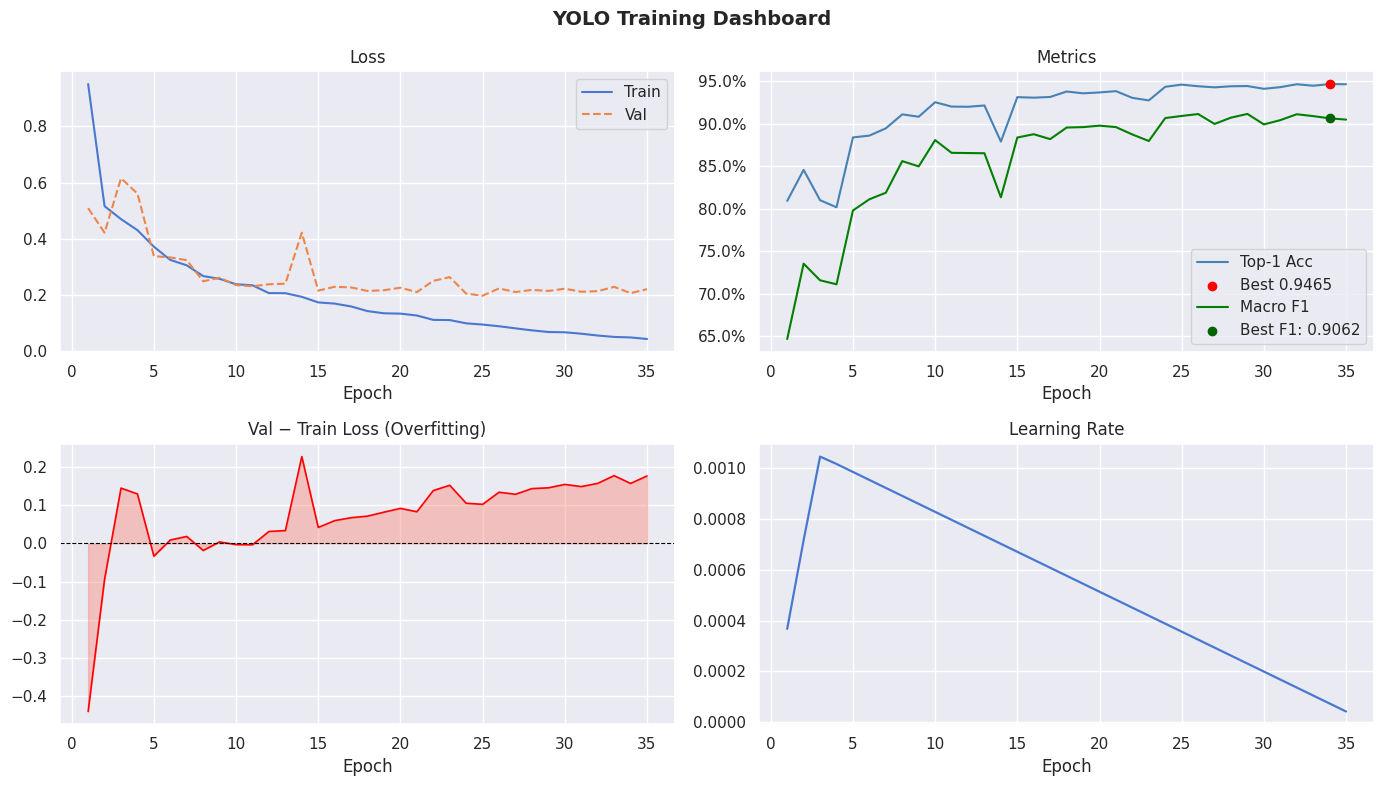

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1 Loss curves
ax = axes[0, 0]
ax.plot(df["epoch"], df["train/loss"], label="Train")
ax.plot(df["epoch"], df["val/loss"], label="Val", linestyle="--")
ax.set_title("Loss")
ax.set_xlabel("Epoch")
ax.legend()

# 2 Top-1 and macro F1 accuracy
ax = axes[0, 1]
ax.plot(df["epoch"], df["metrics/accuracy_top1"], color="steelblue", label="Top-1 Acc")
ax.scatter(best_acc["epoch"], best_acc["metrics/accuracy_top1"], color="red", zorder=5,
           label=f"Best {best_acc['metrics/accuracy_top1']:.4f}")
if "metrics/macro_f1" in df.columns:
    ax.plot(df["epoch"], df["metrics/macro_f1"], color="green", label="Macro F1")
    ax.scatter(best_acc["epoch"], best_acc["metrics/macro_f1"], color="darkgreen", zorder=5,
               label=f"Best F1: {best_acc['metrics/macro_f1']:.4f}")

ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_title("Metrics")
ax.set_xlabel("Epoch")
ax.legend()

# 3 Overfitting gap
ax = axes[1, 0]
ax.fill_between(df["epoch"], df["loss_gap"], alpha=0.4, color="salmon")
ax.plot(df["epoch"], df["loss_gap"], color="red", linewidth=1.2)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Val − Train Loss (Overfitting)")
ax.set_xlabel("Epoch")

# 4 LR schedule
ax = axes[1, 1]
ax.plot(df["epoch"], df["lr/pg0"], linewidth=1.6)
ax.set_title("Learning Rate")
ax.set_xlabel("Epoch")

fig.suptitle("YOLO Training Dashboard", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Inspecting F1 Score

In [13]:
best_f1 = df.loc[df["metrics/macro_f1"].idxmax()]
print("=== Best Macro F1 Epoch ===")
print(f"  Epoch         : {int(best_f1['epoch'])}")
print(f"  Macro F1      : {best_f1['metrics/macro_f1']:.4f}")
print(f"  Val Loss      : {best_f1['val/loss']:.4f}")
print(f"  Train Loss    : {best_f1['train/loss']:.4f}")
print(f"  Top-1 Accuracy: {best_f1['metrics/accuracy_top1']:.4f}")

=== Best Macro F1 Epoch ===
  Epoch         : 29
  Macro F1      : 0.9114
  Val Loss      : 0.2150
  Train Loss    : 0.0690
  Top-1 Accuracy: 0.9441


## Compare YOLO Single Run Results

In [4]:
run_keys = ["single", "single-10"]

result_csvs = [Path(f"../runs/classify/data/generated/train2_local_run/single_strategy/runs/{rk}/results.csv") for rk in run_keys]
results_dfs = [pd.read_csv(res) for res in result_csvs]

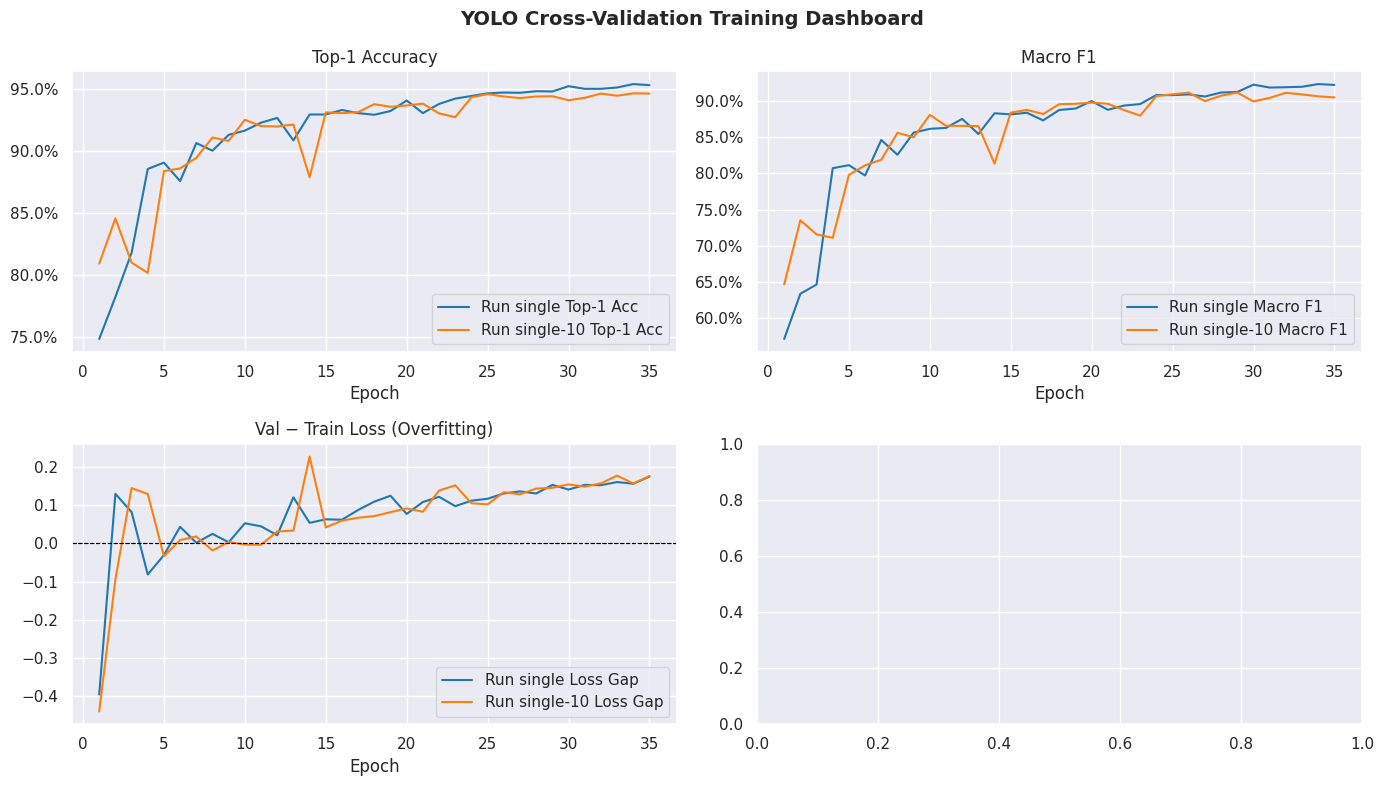

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
colors = sns.color_palette("tab10", n_colors=5)

for run_idx, df in enumerate(results_dfs):

    # 1 Top-1 accuracy
    ax = axes[0, 0]
    ax.plot(df["epoch"], df["metrics/accuracy_top1"], color=colors[run_idx], label=f"Run {run_keys[run_idx]} Top-1 Acc")

    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title("Top-1 Accuracy")
    ax.set_xlabel("Epoch")
    ax.legend()

    # 2 Macro F1
    ax = axes[0, 1]
    if "metrics/macro_f1" in df.columns:
        ax.plot(df["epoch"], df["metrics/macro_f1"], color=colors[run_idx], label=f"Run {run_keys[run_idx]} Macro F1")
        
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
        ax.set_title("Macro F1")
        ax.set_xlabel("Epoch")
        ax.legend()

    # 3 Overfitting gap
    df["loss_gap"] = df["val/loss"] - df["train/loss"]

    ax = axes[1, 0]
    # ax.fill_between(df["epoch"], df["loss_gap"], alpha=0.4, color=colors[fold_idx])
    ax.plot(df["epoch"], df["loss_gap"], color=colors[run_idx], label=f"Run {run_keys[run_idx]} Loss Gap")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title("Val − Train Loss (Overfitting)")
    ax.set_xlabel("Epoch")
    ax.legend()


fig.suptitle("YOLO Cross-Validation Training Dashboard", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## YOLO Cross-Validation Results

In [2]:
yolo_cv_resutls_repo = "/workspace/github/pig_posture_kaggle_project/runs/classify/data/generated/train2_local_run/cv_strategy/runs/"
fold_results = []
for fold_idx in range(5):
    fold_results.append(pd.read_csv(f"{yolo_cv_resutls_repo}/fold_{fold_idx}/results.csv"))

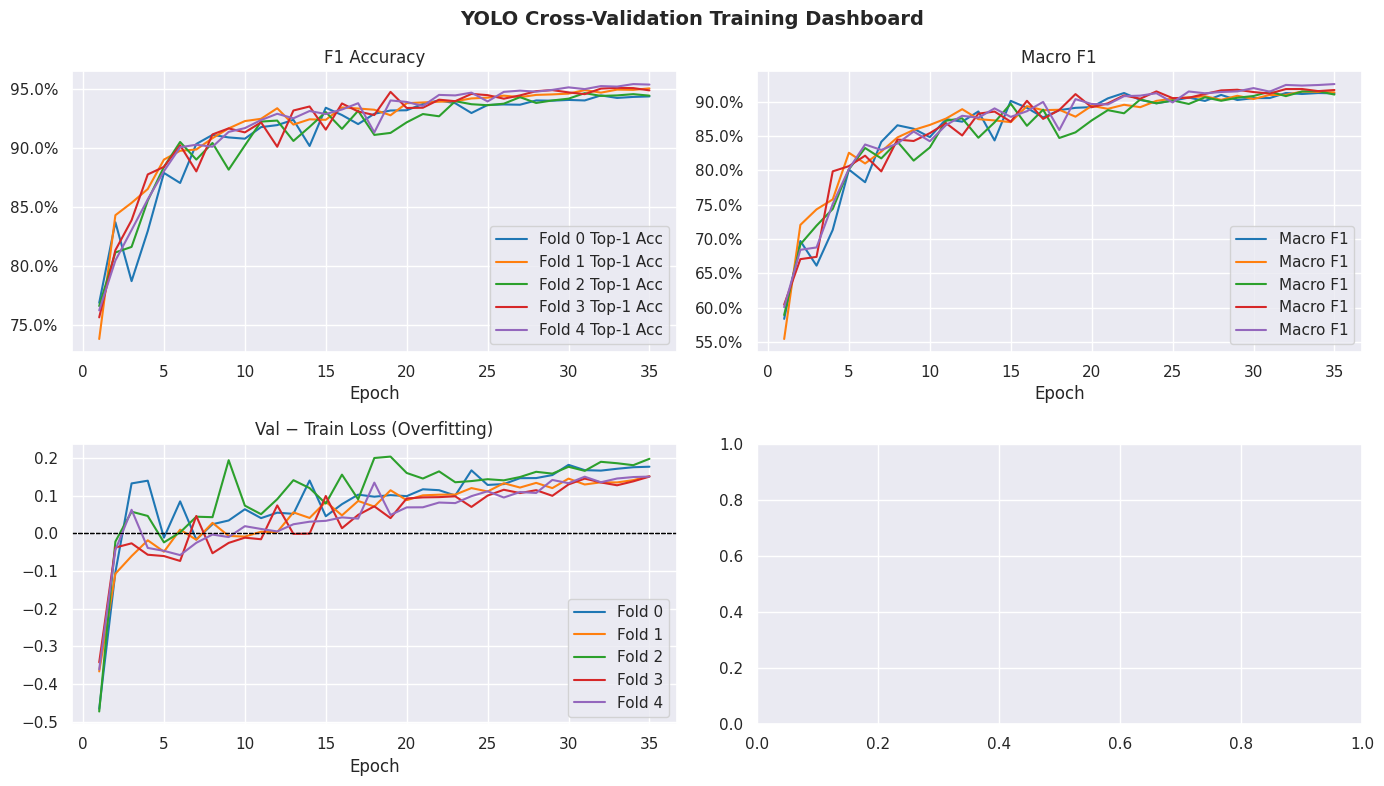

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
colors = sns.color_palette("tab10", n_colors=5)

for fold_idx, df in enumerate(fold_results):

    # 1 Top-1 accuracy
    ax = axes[0, 0]
    ax.plot(df["epoch"], df["metrics/accuracy_top1"], color=colors[fold_idx], label=f"Fold {fold_idx} Top-1 Acc")

    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_title("F1 Accuracy")
    ax.set_xlabel("Epoch")
    ax.legend()

    # 2 Macro F1
    ax = axes[0, 1]
    if "metrics/macro_f1" in df.columns:
        ax.plot(df["epoch"], df["metrics/macro_f1"], color=colors[fold_idx], label="Macro F1")
        
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
        ax.set_title("Macro F1")
        ax.set_xlabel("Epoch")
        ax.legend()

    # 3 Overfitting gap
    df["loss_gap"] = df["val/loss"] - df["train/loss"]

    ax = axes[1, 0]
    # ax.fill_between(df["epoch"], df["loss_gap"], alpha=0.4, color=colors[fold_idx])
    ax.plot(df["epoch"], df["loss_gap"], color=colors[fold_idx], label=f"Fold {fold_idx}")
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title("Val − Train Loss (Overfitting)")
    ax.set_xlabel("Epoch")
    ax.legend()


fig.suptitle("YOLO Cross-Validation Training Dashboard", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()